# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Lane:** Refresh / Content Opportunity Scoring.

**Question:** Given limited content-review capacity, which pages should a reviewer inspect
first for refresh or CTR/engagement work — using only signals that are knowable at
decision time (search visibility, position, CTR, freshness, engagement)?

**Decision this supports:** a content team cannot review every page every month. This
work produces a ranked, reason-coded review queue so a human reviewer works the highest-
opportunity pages first, instead of reviewing pages in an arbitrary or purely-recency order.

**Task framing:** ranking/scoring, not causal inference. Evaluated with **precision@K**
(primarily **precision@50**) because the real constraint is "how many pages can a reviewer
actually get through," not overall classification accuracy. The label used throughout
(`is_declining_label`) is an explicit **proxy** — see Limitations — not a claim about what
caused any page's performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Two FlyRank sources were used, at different stages of the project:

**Starter release — `content_refresh_anonymized.csv`** (used for the shipped model, W1-W2, W4-W7)
- 30,000 rows, one row per pseudonymized `content_id`, 32 pseudonymized `client_id`s, 44 columns.
- Label used: `is_declining_label = (trend_direction == "down")`, base rate **0.542**.
- No date window beyond "current snapshot" — this is a single cross-sectional pull, not a
  time series. That is a limitation, named explicitly below.

**Warehouse release — `fact_content_daily_performance`** (Hugging Face, `month=2026-03` partition;
used for a data-contract + leakage dry run in W3, not for the shipped model)
- Grain: one row per `report_date` x `client_hash_id` x `content_hash_id` (page-day).
- 9,841,378 rows, 55 clients, 331,437 content items, 2026-03-01 to 2026-03-31.
- Feature window: first half of March (03-01 to 03-15). Label window: second half (03-16 to
  03-31) — a genuine future-window split, used to demonstrate a proper temporal contract and a
  deliberate leakage trap (below), not to train the model that ships in this capstone.

**Excluded / not used as features, either release:** `content_id` / `client_id` (grouping and
split-validation only, never a feature), `trend_direction` / `trend_pct` (proxy-source columns —
using them as features would leak the label), any raw target-window metric, and all raw
client names, domains, URLs, or queries (public-safe by construction — the released data is
already pseudonymized).

**Why the starter CSV, not the warehouse, for the final model:** the warehouse work in W3 was a
methodological dry run that proved a proper future-window label and leakage check *can* be
built, but the capstone's modeling and playbook (W5-W7) run on the starter CSV's proxy label
for continuity with the W4 baseline. This gap — proxy label vs. true future-window label — is
named directly in Limitations rather than hidden.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `is_declining_label = (trend_direction == "down")`, a proxy for "this page needs
attention," base rate 0.542. Not a causal outcome — see Limitations.

**Features (final model, 20 numeric + 8 categorical):** log-scaled traffic/impressions/clicks/
sessions (90d), `avg_position`, `ctr`, `engagement_rate`, `scroll_rate`, `content_age_days`,
`days_since_last_update`, `word_count`/`char_count`, availability flags (`has_position_data`,
`has_word_count`, `has_keyword_data`), plus categorical tiers (`freshness_tier`, `age_tier`,
`word_count_tier`, `impression_tier`, `position_tier`, `competition_level`, `content_type`,
`main_intent`).

**Forbidden / excluded from features (confirmed `leaked = []`):** `trend_direction`,
`trend_pct`, any `*_last_30d` / `*_prev_30d` column (label-adjacent), `content_id`, `client_id`.

**Baseline (W4, transparent rule, no training):**
`baseline_action_score = visible_band x reachable_position x log1p(impressions_90d) x
(1 + 0.45*stale_flag + 0.35*low_ctr_flag + 0.25*fresh_age_flag)`
— built from two audited signals: CTR-vs-position (**CONFIRMED**: low-CTR rate rises from
0.79 near top positions to 0.96 by position 50+) and staleness (**MIXED**: decline rate is
elevated at 91-180 days but a tiny 181+ bucket, n=174, reverses the trend).

**Model:** logistic regression (`class_weight="balanced"`), checked against a random forest
(more complex, not better — rejected) and the recomputed W4 rule, all scored on the identical
held-out split.

**Validation design:** `GroupShuffleSplit` by `client_id`, 75/25, `random_state=42` — grouped
so no client appears in both train and test, because pages from the same client share
portfolio-level quirks a model could otherwise memorize instead of generalize from.
Train: 22,885 rows / 24 clients. Test: 7,115 rows / 8 clients (base rate 0.517).

**Leakage checks performed:**
1. Forbidden-feature scan on the final feature set — passed, none present.
2. "Train-without-suspect" test on the top feature (`log_impressions_90d`): average precision
   0.607 with it vs. 0.600 without — no collapse, so no single feature is silently carrying
   the label.
3. Naive **random split** was run for comparison (not shipped) and showed a materially
   inflated precision@50 of 0.88 vs. the grouped split's 0.76 — a 0.12 gap attributable to
   per-client memorization. The grouped-split number is the one this paper reports.
4. Separately, on the warehouse release (W3), a deliberately planted leak column
   (`leaky_decline_hint` = the label itself) was shown to push ROC AUC from an honest 0.587
   to a suspicious 1.000 — confirming the leakage check catches an obvious leak before it
   ships, and that honest AUC on that release sits far lower than a leaked run.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

All three methods scored on the **identical held-out test set** (7,115 rows, 8 clients never
seen in training, base rate 0.517):

| method | P@10 | P@20 | **P@50** | P@100 | avg precision | ROC AUC |
|---|---|---|---|---|---|---|
| **Logistic regression (shipped)** | 0.90 | 0.75 | **0.76** | 0.70 | 0.607 | 0.612 |
| Random forest (complexity check) | 0.50 | 0.40 | 0.54 | 0.57 | 0.590 | 0.605 |
| Week-4 baseline rule | 0.80 | 0.65 | 0.42 | 0.54 | 0.519 | 0.514 |
| base rate (chance) | — | — | 0.517 | — | — | 0.50 |

**Headline result:** the model reviews the top 50 pages in its queue and **76% of them are
genuinely declining** by the proxy label — up from **42%** for the transparent baseline rule,
on the same 50 pages, same clients, same split. The random forest (more parameters) did not
beat either the logistic regression or, on P@50, even the simple baseline — complexity was
tried and explicitly rejected.

**Honesty check on the split itself:** the same model run on a naive random split (not
client-grouped) reported precision@50 = 0.88 — 12 points higher than the grouped-split 0.76.
That gap is the cost of letting the same client appear in both train and test; the grouped
number (0.76) is the one used everywhere else in this paper.

In [1]:
import json
import pandas as pd

with open("../outputs/w05_model_metrics.json") as f:
    model_metrics = json.load(f)
with open("../outputs/baseline_action_score_metrics.json") as f:
    baseline_metrics = json.load(f)

comparison = pd.DataFrame(model_metrics["comparison"])[
    ["method", "precision_at_10", "precision_at_20", "precision_at_50",
     "precision_at_100", "average_precision", "roc_auc"]
]
print("Held-out test set (client-grouped split), same rows for all methods:")
print(f"  test_rows={model_metrics['split']['test_rows']}, "
      f"test_clients={model_metrics['split']['test_clients']}, "
      f"test_base_rate={model_metrics['split']['test_base_rate']:.3f}")
comparison

Held-out test set (client-grouped split), same rows for all methods:
  test_rows=7115, test_clients=8, test_base_rate=0.517


,method,precision_at_10,precision_at_20,precision_at_50,precision_at_100,average_precision,roc_auc
0,logistic_regression,0.9,0.75,0.76,0.70,0.607425,0.611579
1,random_forest_check,0.5,0.40,0.54,0.57,0.590296,0.605013
2,week4_baseline_rule,0.8,0.65,0.42,0.54,0.518587,0.513853


- **Proxy label, not ground truth.** `is_declining_label` comes from `trend_direction`, a
  snapshot-derived proxy for "needs attention" — not a causal or independently-verified outcome.
  A page can be flagged "declining" and still be performing fine by other criteria.
- **~1 in 4 top-50 flags will be wrong.** Precision@50 = 0.76 means roughly 24% of the top-50
  queue is not actually declining by the proxy. This is a triage aid, not a verdict on any
  single page.
- **Single snapshot, single portfolio.** The shipped model trains and tests on one 30,000-row
  cross-sectional pull from 32 clients. It has not been tested across other verticals, other
  time periods, or a genuine future-window label (the warehouse dry run in the Data section
  shows that harder setup is buildable, but it isn't what shipped).
- **Reason codes are rule-based explanations layered on a probabilistic score** — they describe
  a plausible reason a page scored high, not proof that reason caused the score or the decline.
- **Freshness/age features are snapshot-frozen.** `content_age_days` and
  `days_since_last_update` are valid for this static dataset but would need to be recomputed on
  every scoring run in a live system — they are not automatically "live" features.
- **The staleness signal is mixed, not confirmed.** Decline rate rises through 91-180 days but
  reverses in the 181+ bucket — and that bucket has only 174 rows, too small to trust on its own.
- **FlyRank's own published "freshness multiplier" claim (3.2x health, 57x impressions) rests
  partly on an unstable comparison** — the paper's own 361+ day bucket has a 283:1 ratio built
  on a denominator of 1 declining page. This capstone uses the paper's more stable 31-90 day
  window (7.88:1, larger n) instead, and flags rather than repeats the unstable number.
- **Language discipline:** every claim in this paper uses *observed*, *directional*, or
  *decision-support* language — never *proves*, *causes*, or *guarantees*. This queue is built
  for a human reviewer to work top-down, not for unattended automation, publishing, deletion,
  or client-facing claims (see the no-go list in the recommendations section).

The held-out predictions (7,115 pages, 8 clients never seen in training) feed a five-code
priority queue. Sorting purely by model score surfaces near-dead pages first (0% CTR, almost
no traffic) — technically "confidently declining" but with nothing left to recover, so those
correctly route to *monitor only*. The **actionable queue** filters those out
(`effort_tier != "none"`, 3,859 of 7,115 pages = 54.2%) and sorts by opportunity value, then
model confidence — this is the order a reviewer should actually work.

| Reason code | Pages | Action | Effort |
|---|---|---|---|
| `LOW_CTR_VISIBLE` | 1,949 | Rewrite title/meta and snippet | low |
| `STALE_UPDATE_DUE` | 367 | Refresh and expand content | medium |
| `AGING_REACHABLE` | 1,543 | Schedule editorial review before the decay window | medium |
| `LOW_VISIBILITY` | 2,429 | Monitor only — not enough demand to prioritize | none |
| `WATCH_LIST` | 827 | No action yet | none |

**Thresholds triangulated across three independent findings:** the STALE/AGING cutoff (91+
days) draws on (1) this project's own signal audit — freshness_tier 91-180 has the highest
decline rate observed (0.611); (2) FlyRank's published decay-cliff finding around 271-365 days;
and (3) FlyRank's freshness-refresh finding, using its stable 31-90 day window rather than its
unstable 361+ day bucket (see Limitations).

**Intended use:** a ranked review queue for a human content reviewer or strategist.
**Never automate from this queue:** publishing, deletion/deindexing, client-facing guarantees,
or bulk unattended edits — especially on YMYL or high-stakes content. A human must still check
content accuracy, brand voice, and context the model can't see (seasonality, discontinued
products, legal/compliance).

**Monitoring triggers for this queue in production** (illustrative, not yet operational):
precision@50 floor 0.60, base-rate drift limit ±0.10, WATCH_LIST share limit 25%, quarterly
refit cadence, mandatory caution on any newly onboarded client. All three checked triggers
currently read "ok" against this run.

In [2]:
with open("../outputs/w07_playbook_summary.json") as f:
    playbook = json.load(f)

print(f"Actionable queue: {playbook['n_actionable_rows']} / {playbook['n_queue_rows']} pages "
      f"({playbook['n_actionable_rows'] / playbook['n_queue_rows']:.1%})")
print(f"Model precision@50: {playbook['model_precision_at_50']}  "
      f"vs baseline precision@50: {playbook['baseline_precision_at_50']}")
print(f"needs_senior_review flagged: {playbook['needs_senior_review_rows']} pages "
      "(placeholder heuristic, not a real compliance classifier)\n")

reason_codes = pd.Series(playbook["reason_code_counts"]).sort_values(ascending=False)
reason_codes.name = "pages"
reason_codes

Actionable queue: 3859 / 7115 pages (54.2%)
Model precision@50: 0.76  vs baseline precision@50: 0.42
needs_senior_review flagged: 697 pages (placeholder heuristic, not a real compliance classifier)



LOW_VISIBILITY      2429
LOW_CTR_VISIBLE     1949
AGING_REACHABLE     1543
WATCH_LIST           827
STALE_UPDATE_DUE     367
Name: pages, dtype: int64

Committed figures and data receipts the deployed paper embeds or links to:

- `work/figures/w07_precision_at_50_comparison.png` — model (0.76) vs. baseline (0.42) vs.
  base-rate reference (0.52) at precision@50. The paper's headline chart.
- `work/figures/w07_reason_code_distribution.png` — the five-reason-code breakdown of the
  held-out queue.
- `work/outputs/w05_model_metrics.json` — full model-vs-baseline-vs-RF comparison table
  (source of the Results section numbers above).
- `work/outputs/baseline_action_score_metrics.json` — W4 baseline queue metrics.
- `work/outputs/w07_playbook_summary.json` — committed receipt for the final action queue
  (source of the Recommendations section numbers above).
- `work/outputs/w05_model_test_predictions.csv` / `work/outputs/w07_action_queue.csv` —
  regenerated, git-ignored (not committed — datasets never go into the repo).

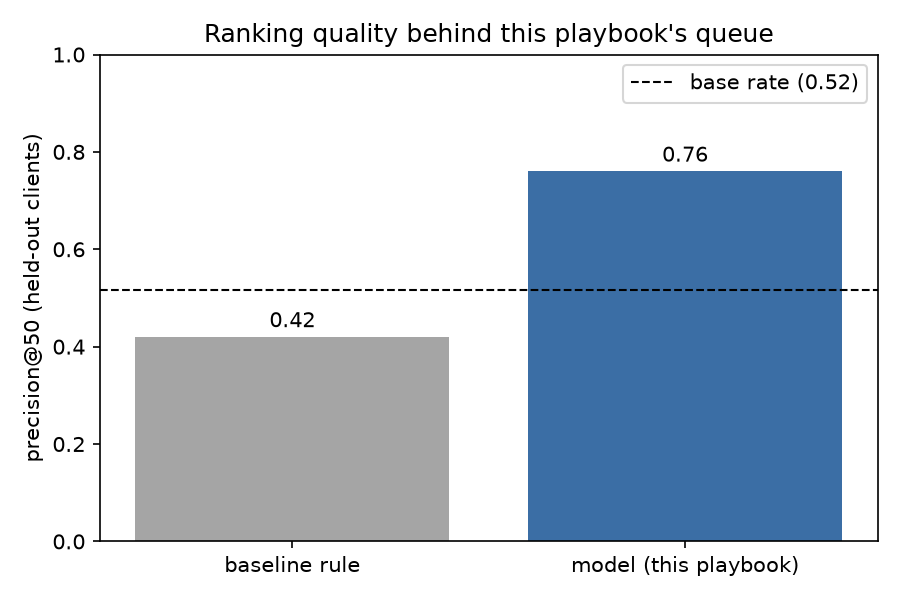

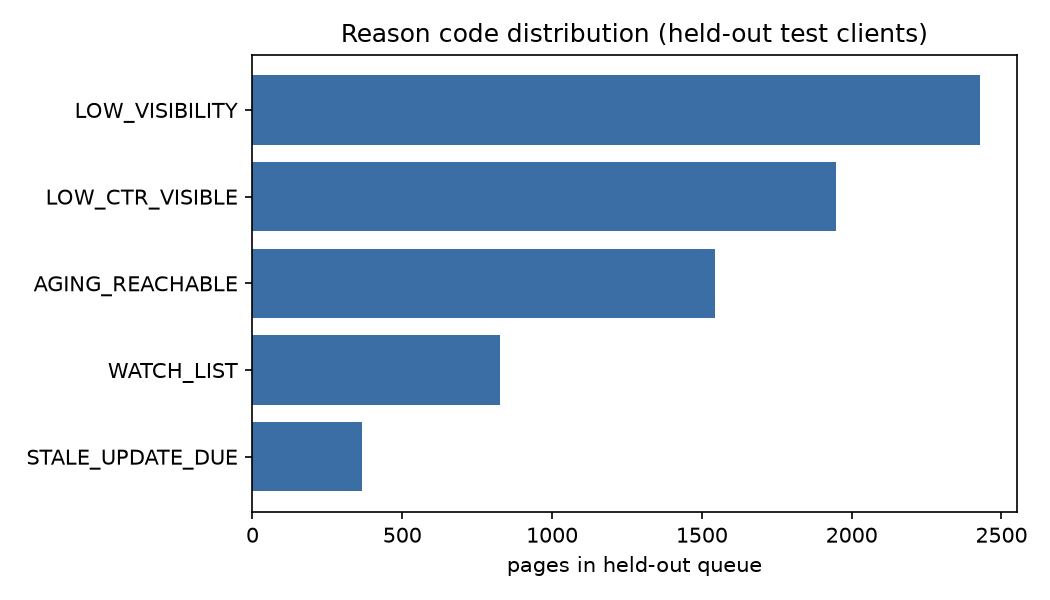

In [3]:
from IPython.display import Image, display

display(Image(filename="../figures/w07_precision_at_50_comparison.png"))
display(Image(filename="../figures/w07_reason_code_distribution.png"))

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.